# Packages

In [ ]:
! pip install datasets plotly nbformat seaborn matplotlib scipy numpy pandas scikit-learn -q


# Données

In [1]:
import requests
import pandas as pd

url = "https://datasets-server.huggingface.co/rows"

all_rows = []

for offset in range(0, 1000, 100):
    params = {
        "dataset": "Uris001/credit-risk-eda",
        "config": "default",
        "split": "train",
        "offset": offset,
        "length": 100
    }

    response = requests.get(url, params=params).json()

    if "rows" not in response:
        break

    all_rows.extend([row["row"] for row in response["rows"]])

df = pd.DataFrame(all_rows)
print(df.head())

   Age  Annual Income Home Ownership  Employment Length (Years) Loan Purpose  \
0   21           9600            OWN                        5.0    EDUCATION   
1   25           9600       MORTGAGE                        1.0      MEDICAL   
2   23          65500           RENT                        4.0      MEDICAL   
3   24          54400           RENT                        8.0      MEDICAL   
4   21           9900            OWN                        2.0      VENTURE   

  Loan Grade  Loan Amount  Interest Rate  Default Status  Loan % of Income  \
0          B         1000          11.14               0              0.10   
1          C         5500          12.87               1              0.57   
2          C        35000          15.23               1              0.53   
3          C        35000          14.27               1              0.55   
4          A         2500           7.14               1              0.25   

  Previous Default  Credit History Length (Years) 

In [65]:
from datasets import load_dataset

ds = load_dataset("Uris001/credit-risk-eda")

data = ds["train"].to_pandas()
print(data.shape)

(31415, 16)


In [66]:
data.head()

,Age,Annual Income,Home Ownership,Employment Length (Years),Loan Purpose,Loan Grade,Loan Amount,Interest Rate,Default Status,Loan % of Income,Previous Default,Credit History Length (Years),LTI Group,Income Group,Age Group,Interest Rate Group
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,No,2,Low,Very Low,18–25,Medium
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,No,3,Very High,Very Low,18–25,High
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,No,2,Very High,High,18–25,Very High
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Yes,4,Very High,Medium,18–25,Very High
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,No,2,High,Very Low,18–25,Very Low


In [67]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31415 entries, 0 to 31414
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            31415 non-null  int64  
 1   Annual Income                  31415 non-null  int64  
 2   Home Ownership                 31415 non-null  object 
 3   Employment Length (Years)      31415 non-null  float64
 4   Loan Purpose                   31415 non-null  object 
 5   Loan Grade                     31415 non-null  object 
 6   Loan Amount                    31415 non-null  int64  
 7   Interest Rate                  31415 non-null  float64
 8   Default Status                 31415 non-null  int64  
 9   Loan % of Income               31415 non-null  float64
 10  Previous Default               31415 non-null  object 
 11  Credit History Length (Years)  31415 non-null  int64  
 12  LTI Group                      31415 non-null 

In [93]:
from statistique_descriptive import Statistique_Descriptives
from statistique_descriptive import analyse_categorielle


# I. Statistiques descriptives Univariée

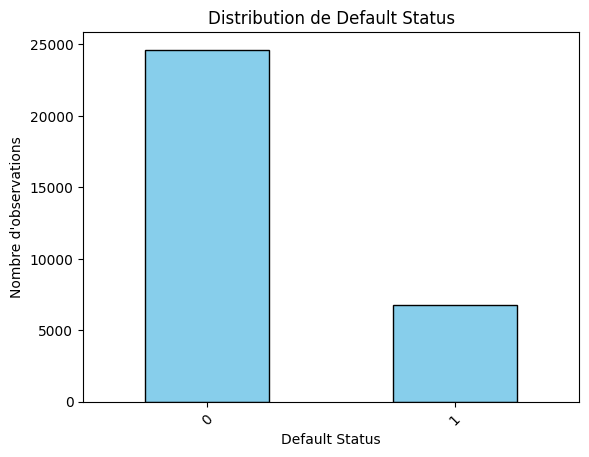

--- Default Status ---
Default Status
0    24641
1     6774
Name: count, dtype: int64




In [94]:
analyse_categorielle(data, "Default Status")

### Statistiques descriptives de l'Âge des clients

Un premier contrôle exploratoire montre que l'âge des individus est dans une fourchette assez raisonnable comprise entre 20 et 84 ans. Cela semble très normale vu la situation des individus et l'esperance de vie à la naissance. 

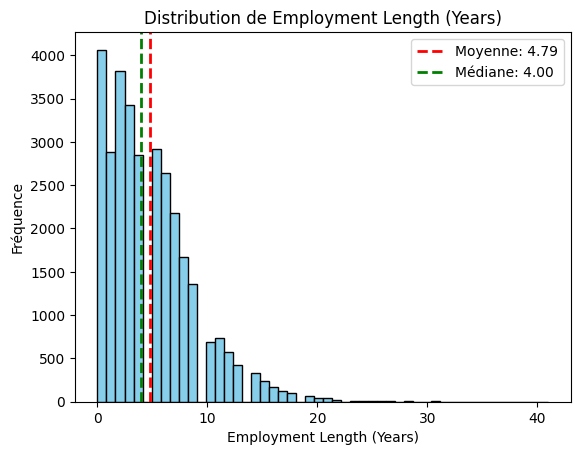

In [96]:
Statistique_Descriptives(data, "Employment Length (Years)")

### Analyse des données des taux d'interet

Les informations sur les taux d'interet montre que le mode est obtenus pour des valeurs proches de 7,5% ce qui reflète reellement la nature des taux d'interet sur les prèts bancaires. 

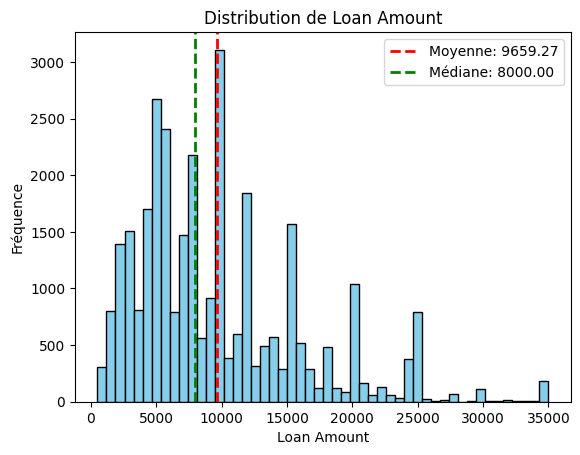

In [98]:
Statistique_Descriptives(data, "Loan Amount")

### Analyse des defaut précedement des clients

Seulement 17,5% des clients avait fait un defaut sur leur credit precedemment.

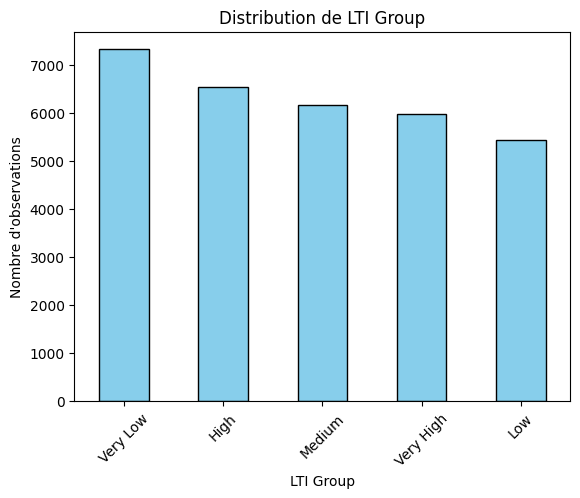

--- LTI Group ---
LTI Group
Very Low     7321
High         6528
Medium       6157
Very High    5981
Low          5428
Name: count, dtype: int64




In [100]:
analyse_categorielle(data, "LTI Group")

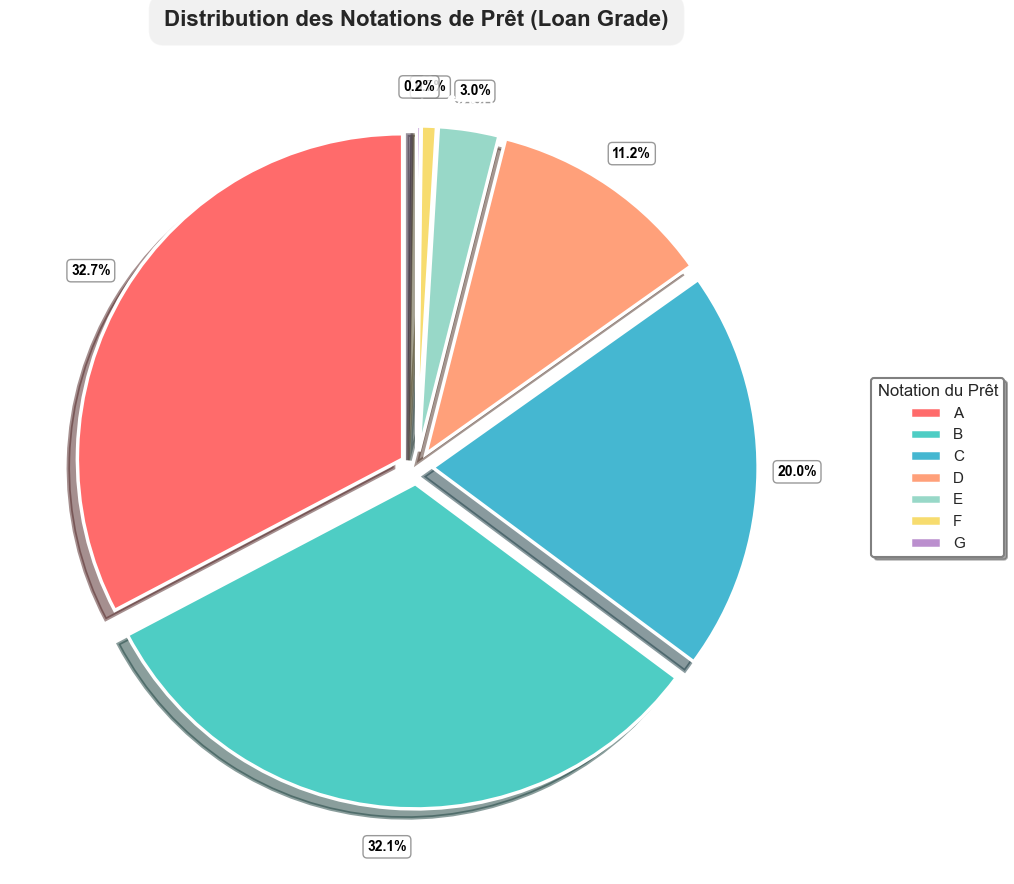

In [163]:
# Calcul des statistiques par grade 
grade_stats = data.groupby('Loan Grade')['Default Status'].agg(['mean', 'count']).reset_index()
grade_stats.columns = ['Loan Grade', 'Default Rate', 'Count']


# Création de la figure avec taille augmentée
fig, ax = plt.subplots(figsize=(12, 9))

# Palette de couleurs 
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE']
colors = colors[:len(grade_stats)]

# Écartement des parts 
explode = [0.05] * len(grade_stats)

# Tracé du camembert amélioré
wedges, texts, autotexts = ax.pie(
    grade_stats['Count'],
    labels=labels_interieurs,          # À l'intérieur des parts
    autopct='%1.1f%%',                 # Pourcentages générés automatiquement
    startangle=90,
    pctdistance=1.12,                  # Distance des pourcentages
    colors=colors,
    explode=explode,                   # Écarte légèrement les parts
    textprops={'fontsize': 12, 'weight': 'bold', 'color': 'white'},  # labels intérieurs blancs
    wedgeprops={
        'edgecolor': 'white', 
        'linewidth': 2.5,               # bordure plus épaisse
        'antialiased': True
    },
    shadow=True                         # Ajoute une ombre pour l'effet 3D
)

# Personnalisation des pourcentages 
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(10)
    autotext.set_weight('bold')
    autotext.set_bbox(dict(
        boxstyle='round,pad=0.3', 
        facecolor='white', 
        edgecolor='gray',
        linewidth=1,
        alpha=0.8
    ))

# Labels intérieurs améliorés
for text in texts:
    text.set_fontsize(13)
    text.set_weight('bold')

# Titre amélioré
ax.set_title(
    'Distribution des Notations de Prêt (Loan Grade)', 
    fontsize=16, 
    fontweight='bold', 
    pad=25,
    bbox=dict(boxstyle='round,pad=0.7', facecolor='lightgray', alpha=0.3)
)

# Légende des couleurs 
legend = ax.legend(
    wedges,
    grade_stats['Loan Grade'],
    title="Notation du Prêt",
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),        # position à droite, légèrement décalée
    fontsize=11,
    title_fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True
)

# Amélioration du style de la légende
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('gray')
legend.get_frame().set_linewidth(1.5)

plt.tight_layout()
plt.show()


# Motifs du prêt

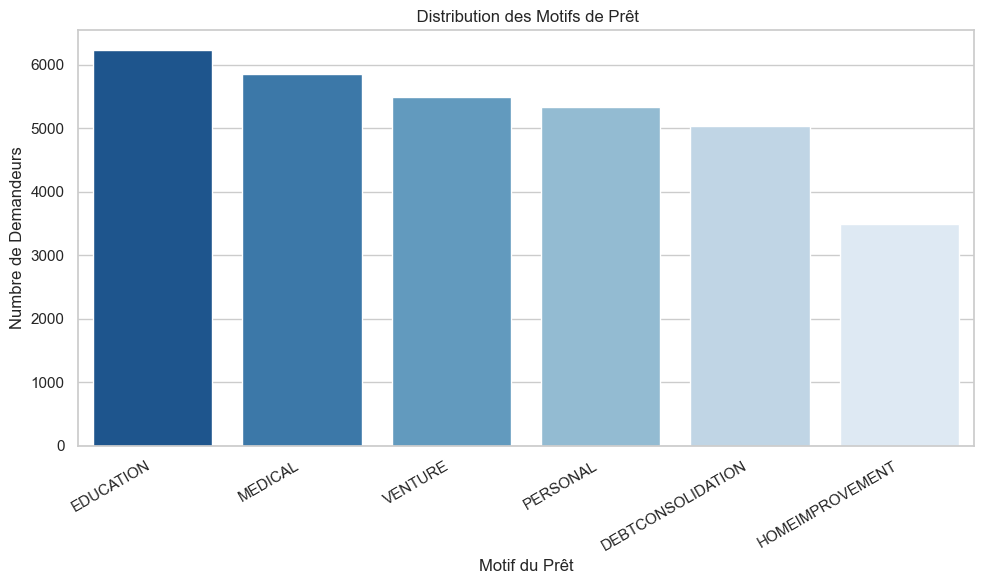

In [ ]:

plt.figure(figsize=(10,6))

order = data['Loan Purpose'].value_counts().index

sns.countplot(
    data=data,
    x='Loan Purpose',
    order=order,
    palette='Blues_r'
)

plt.title(' Distribution des Motifs de Prêt')
plt.xlabel('Motif du Prêt')
plt.ylabel('Nombre de Demandeurs')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


### Interprétation : 
- La demande de prêts se répartit entre plusieurs motifs, les prêts destinés à l'éducation, aux soins médicaux, à l'entrepreneuriat et aux besoins personnels représentent les segments les plus importants.
- Les prêts pour la rénovation domiciliaire semblent nettement moins importants, tandis que les prêts de consolidation de dettes détiennent toujours une part significative.

# II. Statistique descriptives bivariées

### Objectif n°1: Comment la notation des prêts reflète-t-elle efficacement le risque de défaut de paiement de l'emprunteur?

In [144]:
#résumé par grade de prêt
pd.set_option('display.float_format', '{:,.2f}'.format)
default_summary(data, 'Loan Grade')

,Loan Grade,total,defaults,default_rate,ci_lower,ci_upper
0,A,10274,982,0.10,0.09,0.10
1,B,10088,1611,0.16,0.15,0.17
2,C,6283,1274,0.20,0.19,0.21
3,D,3529,2075,0.59,0.57,0.60
4,E,943,605,0.64,0.61,0.67
5,F,234,164,0.70,0.64,0.76
6,G,64,63,0.98,0.95,1.00


### interprétation:
1. Observation des tendances
- Le graphique montre une séparation très nette entre les grades A–C (faible risque) et D–G (risque élevé) :
- Grades A, B, C : taux de défaut compris entre environ 12 % et 20 %.
- Grades D, E, F : taux de défaut beaucoup plus élevés, de 58 % à 72 %.
- Le taux de défaut de référence global est de 21,6 %.
- Cette rupture brutale entre C et D indique que le système de notation ne suit pas une échelle linéaire, mais intègre probablement un seuil de risque strict (par exemple, un score minimum imposé par les politiques de prêt).

2. Déséquilibre des effectifs
- La majorité des prêts (n=10 274 pour A ) se concentre sur les grades A–C.
- Les grades à haut risque (D–F) ne représentent qu’un faible nombre d’observations (par exemple n=943 pour E, n=234 pour F, etc.).
- Ce déséquilibre reflète une stratégie de prêt réaliste : les institutions évitent d’accorder massivement des prêts aux profils les plus risqués.

3. Limites méthodologiques
- Les petits effectifs dans les grades D–F rendent les estimations de taux de défaut moins fiables (intervalles de confiance larges). Une interprétation prudente s’impose.
- La valeur de référence globale (21,6 %) est tirée vers le bas par la surreprésentation des grades A–C.

4. Conclusion stratégique
 Le grade de prêt est un indicateur puissant et synthétique du risque de défaut. Il agrège efficacement des informations financières et comportementales des emprunteurs. Pour une gestion du risque optimale :
- Renforcer la segmentation : traiter les grades A–C et D–G comme deux populations distinctes dans les modèles de scoring.
- Collecter plus de données sur les grades D–G pour affiner les estimations.
- Envisager des seuils d’acceptation plus stricts si le taux de défaut observé (>58 %) est jugé trop élevé.

In [164]:
grade_numeric = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
data['grade_numeric'] = data['Loan Grade'].map(grade_numeric)
features = {
    'Annual Income': 'Income',
    'Loan % of Income': 'LTI',
    'Employment Length (Years)': 'Employment Length',
    'Credit History Length (Years)': 'Credit History'
}

print(f"{'Variable':<25} {'Correlation avec Loan Grade':<25} {'R²':<10}")
print("-" * 60)

for col, label in features.items():
    r, p = stats.pearsonr(data['grade_numeric'], data[col])
    print(f"{label:<25} {r:<25.4f} {r**2:<10.4f}")

prev_numeric = (data['Previous Default'] == 'Yes').astype(int)
r, p = stats.pearsonr(data['grade_numeric'], prev_numeric)
print(f"{'Previous Default':<25} {r:<25.4f} {r**2:<10.4f}")

Variable                  Correlation avec Loan Grade R²        
------------------------------------------------------------
Income                    -0.0066                   0.0000    
LTI                       0.1241                    0.0154    
Employment Length         -0.0487                   0.0024    
Credit History            0.0133                    0.0002    
Previous Default          0.5359                    0.2872    


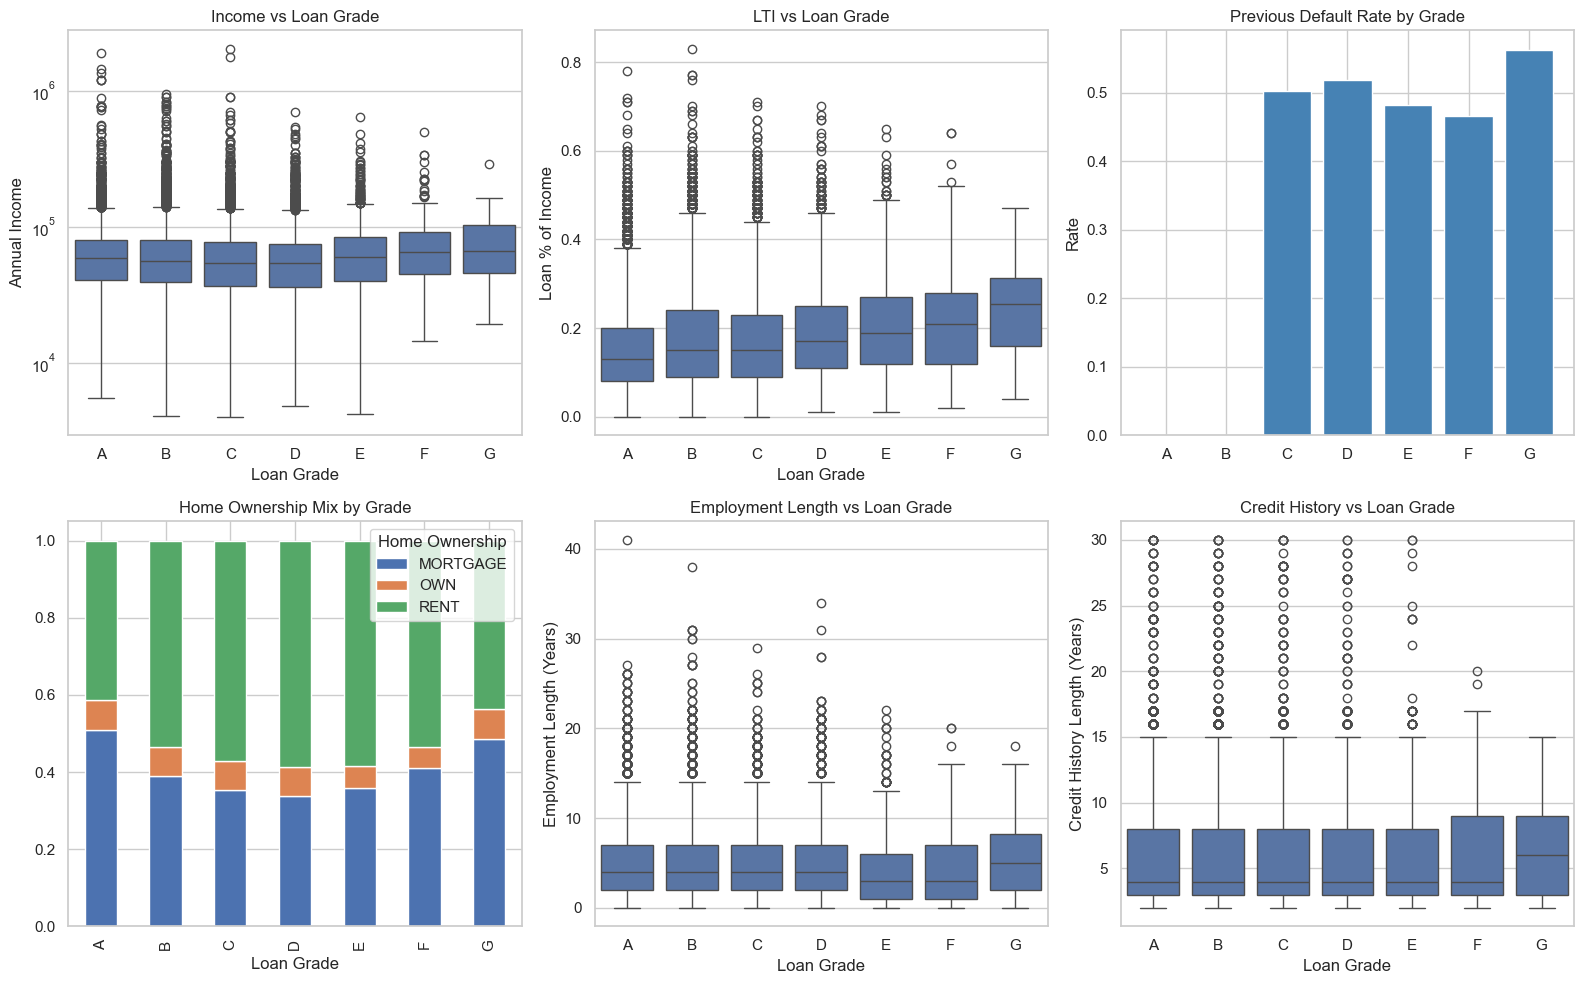

In [193]:
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
grade_numeric = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
data['grade_numeric'] = data['Loan Grade'].map(grade_numeric)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Revenu vs Grade
axes[0,0].set_title('Income vs Loan Grade')
sns.boxplot(data=data, x='Loan Grade', y='Annual Income',
            order=grade_order, ax=axes[0,0])
axes[0,0].set_yscale('log')

# LTI (Loan-to-Income) vs Grade
axes[0,1].set_title('LTI vs Loan Grade')
sns.boxplot(data=data, x='Loan Grade', y='Loan % of Income',
            order=grade_order, ax=axes[0,1])

# Défaut antérieur vs Grade
prev_default_rate = data.groupby('Loan Grade')['Previous Default'].apply(
    lambda x: (x == 'Yes').mean()).reindex(grade_order)
axes[0,2].bar(grade_order, prev_default_rate, color='steelblue')
axes[0,2].set_title('Previous Default Rate by Grade')
axes[0,2].set_ylabel('Rate')

# Type de propriété vs Grade
home_grade = data.groupby(['Loan Grade', 'Home Ownership']).size().unstack(fill_value=0)
home_grade = home_grade.div(home_grade.sum(axis=1), axis=0)
home_grade.reindex(grade_order).plot(kind='bar', ax=axes[1,0], stacked=True)
axes[1,0].set_title('Home Ownership Mix by Grade')

# Ancienneté professionnelle vs Grade
axes[1,1].set_title('Employment Length vs Loan Grade')
sns.boxplot(data=data, x='Loan Grade', y='Employment Length (Years)',
            order=grade_order, ax=axes[1,1])

# Historique de crédit vs Grade
axes[1,2].set_title('Credit History vs Loan Grade')
sns.boxplot(data=data, x='Loan Grade', y='Credit History Length (Years)',
            order=grade_order, ax=axes[1,2])

plt.tight_layout()
plt.show()

La notation du prêt, le ratio d'endettement (LTI), les revenus et les antécédents de défaut fournissent chacun des informations distinctes qui, pour l'essentiel, ne se recoupent pas. Un modèle prédictif devrait traiter ces éléments comme des caractéristiques distinctes, plutôt que de partir du principe que la notation englobe les autres. Les antécédents de crédit et l'ancienneté professionnelle n'apportent qu'une valeur ajoutée minime par rapport à ces prédicteurs fondamentaux.



### Objectif n°2: Les differentes raisons des prets sont-elles relatives au défaut de remboursement du prêt?

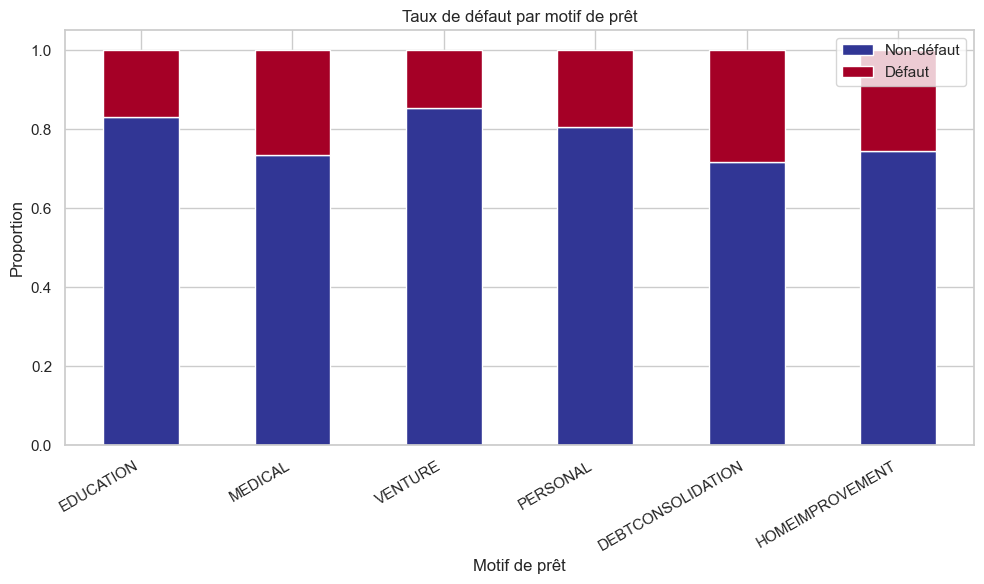

In [ ]:
# Ce graphique visualise le taux de défaut par motif de prêt.
ct = pd.crosstab(
    data['Loan Purpose'],
    data['Default Status'],
    normalize='index'
)

ct = ct.loc[order]  

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='RdYlBu_r'   
)

plt.title('Taux de défaut par motif de prêt')
plt.ylabel('Proportion')
plt.xlabel('Motif de prêt')
plt.xticks(rotation=30, ha='right')
plt.legend(['Non-défaut', 'Défaut'])
plt.tight_layout()
plt.show()

### Les taux de défaut varient selon les motifs :

- Certaines catégories (par exemple, les prêts médicaux, personnels et pour la rénovation domiciliaire) affichent des taux de défaut relativement plus élevés.
- D'autres (par exemple, les prêts pour les études et les prêts d'entreprise) semblent plus stables, avec des taux de défaut plus faibles.
- Cependant, les différences ne sont pas extrêmes et il n'y a pas de séparation nette entre les catégories.


### Analyse du taux de selon le statut de logement des emprunteurs.

On remarque que la base de donnée est très deséquilibré comme on peut le voir ici environ 18% des prets des individus ne sont pas remboursées

### Defaut de paiement en fonction des précedents défauts

On voit ainsi que la situation de defaut precedent d'un client constitue une variable très importante pour anticiper si un individu paiera sa dette ou non.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27024\1240200214.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27024\1240200214.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


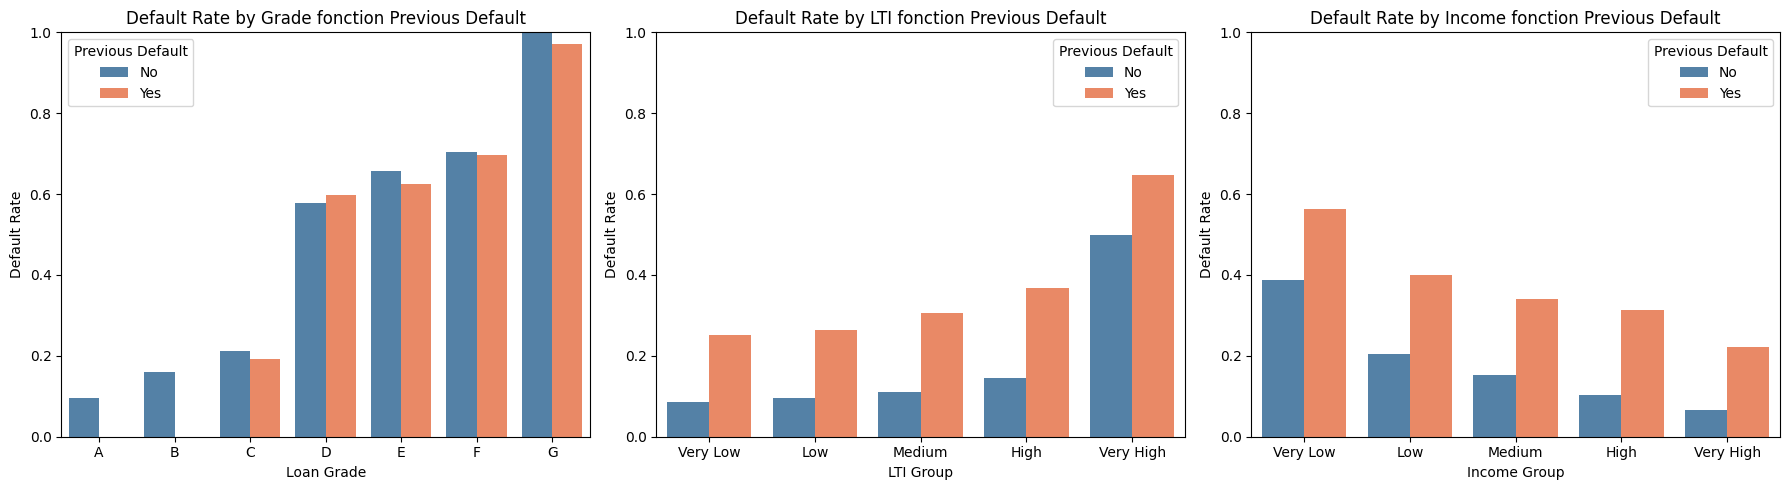

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Create LTI Group before using it
data['LTI Group'] = pd.qcut(data['Loan % of Income'], q=5, labels=["Very Low","Low","Medium","High","Very High"])

# Create Income Group before using it
data['Income Group'] = pd.qcut(data['Annual Income'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# 1. Previous Default x Loan Grade
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
grouped1 = (data.groupby(['Loan Grade', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))

sns.barplot(data=grouped1, x='Loan Grade', y='default_rate',
            hue='Previous Default', order=grade_order,
            ax=axes[0], palette=['steelblue', 'coral'])
axes[0].set_title('Default Rate by Grade fonction Previous Default')
axes[0].set_xlabel('Loan Grade')
axes[0].set_ylabel('Default Rate')
axes[0].set_ylim(0, 1)

# 2. Previous Default x LTI Group
grouped2 = (data.groupby(['LTI Group', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))
lti_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
sns.barplot(data=grouped2, x='LTI Group', y='default_rate',
            hue='Previous Default', order=lti_order,
            ax=axes[1], palette=['steelblue', 'coral'])
axes[1].set_title('Default Rate by LTI fonction Previous Default')
axes[1].set_xlabel('LTI Group')
axes[1].set_ylabel('Default Rate')
axes[1].set_ylim(0, 1)

# 3. Previous Default x Income Group
grouped3 = (data.groupby(['Income Group', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))
income_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
sns.barplot(data=grouped3, x='Income Group', y='default_rate',
            hue='Previous Default', order=income_order,
            ax=axes[2], palette=['steelblue', 'coral'])
axes[2].set_title('Default Rate by Income fonction Previous Default')
axes[2].set_xlabel('Income Group')
axes[2].set_ylabel('Default Rate')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

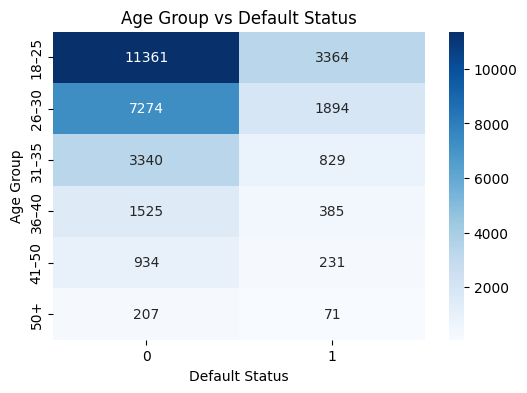

Default Status      0     1
Age Group                  
18–25           11361  3364
26–30            7274  1894
31–35            3340   829
36–40            1525   385
41–50             934   231
50+               207    71


In [115]:
bivarié_cat_cat(data, "Age Group", "Default Status")

### Structure de la correlation

Comme nous l'avons précedemment vu, la nature du credit précedent de la personne influence grandement s'il sera en defaut ou non.

### Encodage ordinale pour la variable Loan Grade

### Utilisation de One-Hot-Encoding pour les variables suivantes
- Home Ownership
- Loan Purpose

### Mapping de Previous Default

## Creation du modèle

In [ ]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

$$
WoE_i = \ln \left( \frac{ \frac{n_i^{(non\_defaut)}}{N^{(non\_defaut)}} }{ \frac{n_i^{(defaut)}}{N^{(defaut)}} } \right)
$$

- WoE > 0  → catégorie "bonne" (plus de non-défauts)
- WoE < 0  → catégorie "risquée" (plus de défauts)
- WoE ≈ 0  → neutre

In [ ]:
def fonction_scoring(X, y, col):
    tab = pd.crosstab(X[col], y)
    
    tab.columns = ['non_def', 'def']
    
    tab['dist_non_def'] = tab['non_def'] / tab['non_def'].sum()
    tab['dist_def'] = tab['def'] / tab['def'].sum()
    
    tab['WoE'] = np.log(tab['dist_non_def'] / tab['dist_def'])
    tab['IV'] = (tab['dist_non_def'] - tab['dist_def']) * tab['WoE']
    
    return tab, tab['IV'].sum()

In [ ]:
woe_maps = {}

for col in features:
    table, _ = fonction_scoring(X_train, y_train, col)
    
    # sauver le mapping WoE
    woe_maps[col] = table['WoE']
    
    # appliquer transformation
    X_train_woe[col] = X_train[col].map(table['WoE'])

In [ ]:
X_train_woe = X_train_woe.fillna(0)
X_test_woe = X_test_woe.fillna(0)

### Prediction du score

### Transformation en score de defaut

In [ ]:
score